# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [3]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [4]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [5]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [6]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [7]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

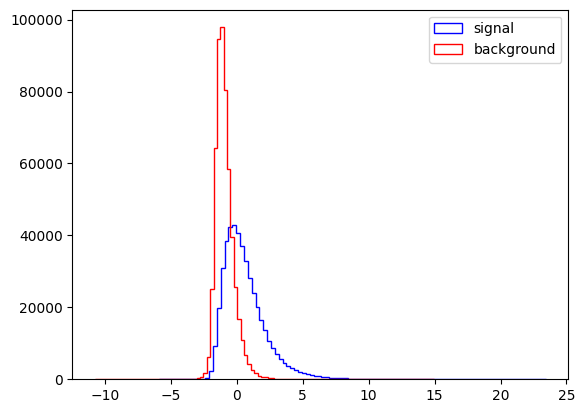

In [8]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

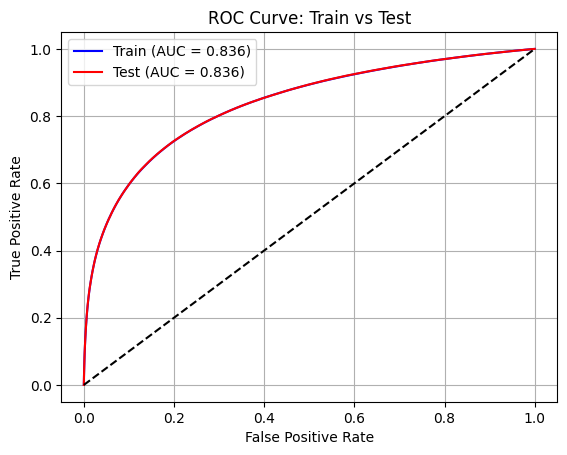

In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

Fisher = LinearDiscriminantAnalysis()
Fisher.fit(X_Train, y_Train)

# Get decision scores for train and test
train_scores = Fisher.decision_function(X_Train)
test_scores  = Fisher.decision_function(X_Test)

# Compute ROC curves
fpr_train, tpr_train, _ = roc_curve(y_Train, train_scores)
fpr_test,  tpr_test,  _ = roc_curve(y_Test,  test_scores)


# Compute AUC values
auc_train = auc(fpr_train, tpr_train)
auc_test  = auc(fpr_test,  tpr_test)


# Plot ROC comparison
plt.figure()

plt.plot(fpr_train, tpr_train, label=f"Train (AUC = {auc_train:.3f})", color="blue")
plt.plot(fpr_test,  tpr_test,  label=f"Test (AUC = {auc_test:.3f})",  color="red")


# Plot random classifier baseline
plt.plot([0,1],[0,1],'k--')


# Labels and formatting for displaying the curves
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Train vs Test")
plt.legend()
plt.grid()
plt.show()

In [16]:
# The training and test ROC curves overlap almost perfectly.
# This indicates that there is no significant overfitting or bias in the model.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

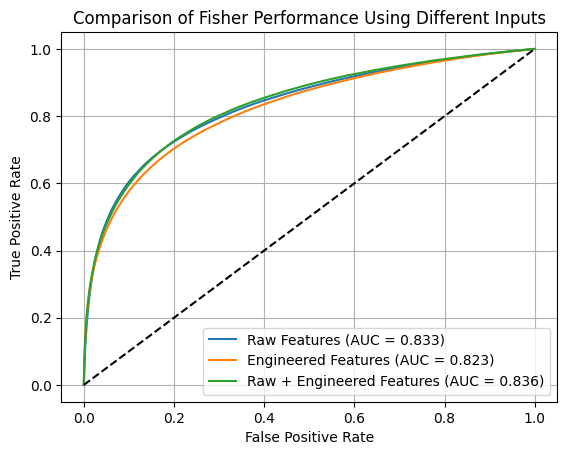

In [14]:
# Define the raw input features
raw_features = [
    "l_1_pT", "l_1_eta","l_1_phi",
    "l_2_pT", "l_2_eta","l_2_phi",
    "MET", "MET_phi"
]

# Define the engineered features (physics-based features)
engineered_features = [
    "MET_rel", "axial_MET", "M_R", "M_TR_2",
    "R", "MT2", "S_R", "M_Delta_R",
    "dPhi_r_b", "cos_theta_r1"
]

# Combine raw and engineered features together
all_features = raw_features + engineered_features


def train_and_evaluate(features):

    # Train the Fisher (LDA) classifier using the given input features
    model = LinearDiscriminantAnalysis()
    model.fit(X_Train[features], y_Train)

    # Compute classifier output on the test sample
    scores = model.decision_function(X_Test[features])

    # Compute ROC curve for the test sample
    fpr, tpr, _ = roc_curve(y_Test, scores)

    # Compute AUC (performance of the classifier)
    roc_auc = auc(fpr, tpr)

    return fpr, tpr, roc_auc


# Train Fisher using raw features
fpr_raw, tpr_raw, auc_raw = train_and_evaluate(raw_features)

# Train Fisher using engineered features
fpr_eng, tpr_eng, auc_eng = train_and_evaluate(engineered_features)

# Train Fisher using raw + engineered features
fpr_all, tpr_all, auc_all = train_and_evaluate(all_features)

plt.figure()

# Compare performance using raw features
plt.plot(fpr_raw, tpr_raw, label=f"Raw Features (AUC = {auc_raw:.3f})")

# Compare performance using engineered features
plt.plot(fpr_eng, tpr_eng, label=f"Engineered Features (AUC = {auc_eng:.3f})")

# Compare performance using raw + engineered features
plt.plot(fpr_all, tpr_all, label=f"Raw + Engineered Features (AUC = {auc_all:.3f})")

# Random classifier reference line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparison of Fisher Performance Using Different Inputs")
plt.legend()
plt.grid()

plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

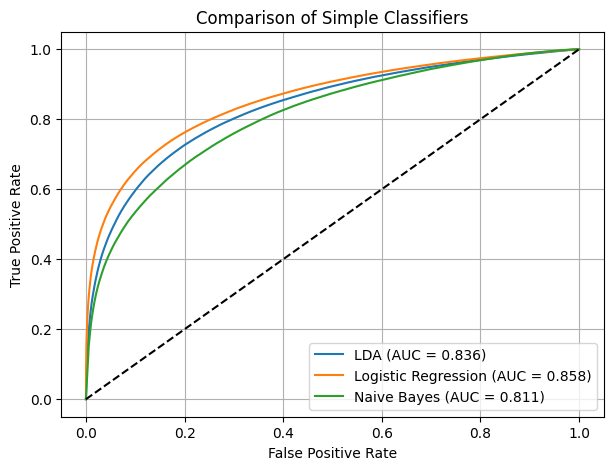

In [18]:
# Part A
# -------

# Import the classifiers
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# Function to train model and compute ROC
def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Get model scores on test data
    # Use decision_function if available, otherwise predict_proba
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
    else:
        scores = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, scores)

    # Compute AUC score
    roc_auc = auc(fpr, tpr)

    return fpr, tpr, roc_auc

# Part B
# -------
# Define the classifiers associated with the techniques I selected
lda = LinearDiscriminantAnalysis()
log_reg = LogisticRegression(max_iter=1000)
nb = GaussianNB()

# Run evaluation for each model
fpr_lda, tpr_lda, auc_lda = evaluate_model(lda, X_Train, y_Train, X_Test, y_Test)
fpr_lr, tpr_lr, auc_lr = evaluate_model(log_reg, X_Train, y_Train, X_Test, y_Test)
fpr_nb, tpr_nb, auc_nb = evaluate_model(nb, X_Train, y_Train, X_Test, y_Test)

# Plot ROC curves
plt.figure(figsize=(7,5))

plt.plot(fpr_lda, tpr_lda, label=f"LDA (AUC = {auc_lda:.3f})")
plt.plot(fpr_lr,  tpr_lr,  label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_nb,  tpr_nb,  label=f"Naive Bayes (AUC = {auc_nb:.3f})")

# Random classifier line
plt.plot([0,1],[0,1],'k--')

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparison of Simple Classifiers")
plt.legend()
plt.grid()

plt.show()

In [22]:
# Part C: Find best score value using Logistic Regression
# -------------------------------------------------------

from sklearn.linear_model import LogisticRegression
import numpy as np


# Train Logistic Regression (best model from Part b)
model = LogisticRegression(max_iter=1000)
model.fit(X_Train, y_Train)


# Get a score for each event in the test data
scores = model.decision_function(X_Test)


# We will try different score values to compare score values to separate signal from background
min_score = min(scores)
max_score = max(scores)

thresholds = np.linspace(min_score, max_score, 100)


# Keep track of best result
best_sigma = 0
best_score_value = 0


# Try each score value
for score_value in thresholds:

    # Count signal events above the score value
    Ns = np.sum((scores > score_value) & (y_Test == 1))

    # Count background events above the score value
    Nb = np.sum((scores > score_value) & (y_Test == 0))

    # Compute Only if there are events left
    if (Ns + Nb) > 0:

        # Compute signal significance
        sigma = Ns / np.sqrt(Ns + Nb)

        # Save best score value
        if sigma > best_sigma:
            best_sigma = sigma
            best_score_value = score_value

# The Final Result
print("Best score value:", best_score_value)
print("Best signal significance:", best_sigma)

Best score value: -0.5984818648639809
Best signal significance: 516.5857858453313


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# Train best model (Logistic Regression from previous parts)
model = LogisticRegression(max_iter=1000)
model.fit(X_Train, y_Train)

# Get scores for test data
scores = model.decision_function(X_Test)

# Get predicted labels (simple classification using 0 threshold)
y_pred = (scores > 0)

# Compute ROC curve values
fpr, tpr, _ = roc_curve(y_Test, scores)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Compute classification metrics
accuracy = accuracy_score(y_Test, y_pred)
precision = precision_score(y_Test, y_pred)
recall = recall_score(y_Test, y_pred)
f1 = f1_score(y_Test, y_pred)

# Compute simple significance
Ns = np.sum((scores > 0) & (y_Test == 1))
Nb = np.sum((scores > 0) & (y_Test == 0))

if (Ns + Nb) > 0:
    sigma = Ns / np.sqrt(Ns + Nb)
else:
    sigma = 0

# Create a simple results table to show outputs neatly
results = pd.DataFrame()
results["Metric"] = ["AUC", "Accuracy", "Precision", "Recall", "F1 Score", "Max Significance"]
results["Value"] = [roc_auc, accuracy, precision, recall, f1, sigma]
print(results)

             Metric       Value
0               AUC    0.858159
1          Accuracy    0.788469
2         Precision    0.829581
3            Recall    0.677568
4          F1 Score    0.745908
5  Max Significance  507.515180
